In [19]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    GradientBoostingClassifier, StackingClassifier, VotingClassifier 
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier

In [20]:
# Loading in the train.csv
df = pd.read_csv('train.csv', na_values=["?"], low_memory=False)
df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


In [21]:
# Figuring out the distribution of NaN values in the dataset

# Total NaN
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

# Amonut of NaN per features
nan_counts = df.isnull().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
nan_df = pd.DataFrame({"NaN Count": nan_counts, "NaN %": nan_pct})
nan_df = nan_df[nan_df["NaN Count"] > 0].sort_values("NaN %", ascending=False)
print(nan_df.to_string())

Total NaN values: 4,648,341
Total cells:      16,894,790
Missing overall:  27.5%

                  NaN Count  NaN %
BIRD_BAND_NUMBER     306465  99.77
ENG_4_POS            303909  98.94
ENROUTE_STATE        301832  98.26
PRECIPITATION        295966  96.35
ENG_3_POS            294822  95.98
LOCATION             267960  87.23
SPEED                212076  69.04
NUM_SEEN             208546  67.89
SKY                  162825  53.01
FLT                  161435  52.55
HEIGHT               154197  50.20
TIME_OF_DAY          133971  43.61
PHASE_OF_FLIGHT      120961  39.38
REG                  118982  38.73
AMO                  116813  38.03
EMO                  113176  36.84
TIME                 109252  35.57
DISTANCE             103303  33.63
COMMENTS             103083  33.56
ENG_2_POS            102509  33.37
EMA                  102421  33.34
AMA                   88896  28.94
TYPE_ENG              87786  28.58
ENG_1_POS             87717  28.56
NUM_ENGS              87697  28.55
AC_MASS 

In [22]:
# Dropping features due to high precentage of NaN
# Additionally dropping random features that act as Identifiers (i.e. INCIDENT_DATE, FLT, REG, LUPDATE, TRANSFER)
drop_cols = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "INCIDENT_DATE", "FLT", "REG", "LUPDATE", "TRANSFER"
]
df.drop(columns=drop_cols, inplace=True)

In [23]:
# Fill the numeric features's NaN value with there respective median  
num_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
            "ENG_1_POS", "ENG_2_POS", "EMA", "EMO"]

train_medians = {}
for col in num_cols:
    if col in df.columns:
        train_medians[col] = df[col].median()
        df[col].fillna(train_medians[col], inplace=True)


C:\Users\karan\AppData\Local\Temp\ipykernel_17224\4061943497.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(train_medians[col], inplace=True)
C:\Users\karan\AppData\Local\Temp\ipykernel_17224\4061943497.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [24]:
# Fill the categorical features's NaN with "Unknow"
cat_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
            "AC_CLASS", "TYPE_ENG", "WARNED", "STATE",
            "FAAREGION", "PERSON", "SOURCE"]
for col in cat_cols:
    if col in df.columns:
        df[col].fillna("Unknown", inplace=True)

C:\Users\karan\AppData\Local\Temp\ipykernel_17224\1571190423.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)


In [25]:
# Fill NUM_STRUCK feature with 1 (most common single-bird strike)
df["NUM_STRUCK"] = pd.to_numeric(df["NUM_STRUCK"], errors="coerce")
df["NUM_STRUCK"].fillna(1, inplace=True)

# Fill NUM_SEEN feature with median
df["NUM_SEEN"] = pd.to_numeric(df["NUM_SEEN"], errors="coerce")
train_medians["NUM_SEEN"] = df["NUM_SEEN"].median()
df["NUM_SEEN"].fillna(train_medians["NUM_SEEN"], inplace=True)

C:\Users\karan\AppData\Local\Temp\ipykernel_17224\396433350.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["NUM_STRUCK"].fillna(1, inplace=True)
C:\Users\karan\AppData\Local\Temp\ipykernel_17224\396433350.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [26]:
# Checking NaN percentage
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

Total NaN values: 472,037
Total cells:      12,901,476
Missing overall:  3.7%



In [27]:
# Convert TIME (HH:MM string) to numeric HOUR, then drop original
# Missing TIME values are imputed with the median hour
df["HOUR"] = pd.to_numeric(
    df["TIME"].str.split(":").str[0], errors="coerce"
)
train_medians["HOUR"] = df["HOUR"].median()
df["HOUR"] = df["HOUR"].fillna(train_medians["HOUR"])
df.drop(columns=["TIME"], inplace=True)

# Drop LATITUDE/LONGITUDE — redundant with STATE and FAAREGION
df.drop(columns=["LATITUDE", "LONGITUDE"], inplace=True)

print("HOUR sample:", df["HOUR"].describe())
print("\nRemaining NaNs:", df.isnull().sum().sum())

HOUR sample: count    307178.000000
mean         12.588639
std           4.616758
min           0.000000
25%          11.000000
50%          12.000000
75%          14.000000
max          23.000000
Name: HOUR, dtype: float64

Remaining NaNs: 281294


In [28]:
# Class balance check
print("Class counts:")
print(df["INDICATED_DAMAGE"].value_counts())

print("\nClass percentages:")
print(df["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))


Class counts:
INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64

Class percentages:
INDICATED_DAMAGE
0    93.64
1     6.36
Name: proportion, dtype: float64


In [29]:
# Scaling the data set 
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Encoding the categorical columns
label_encoders = {}  # store one encoder per column so we can reuse on test set
cat_cols = df.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le # save for test set later
    
# Seperating features and target 
X = df.drop(columns=["INDICATED_DAMAGE", "INDEX_NR"])
y = df["INDICATED_DAMAGE"]

# Scaling Numeric Features
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaling complete. Shape:", X_scaled.shape)
print(X_scaled.describe().round(2))

Scaling complete. Shape: (307178, 38)
       INCIDENT_MONTH  INCIDENT_YEAR  TIME_OF_DAY  AIRPORT_ID    AIRPORT  \
count       307178.00      307178.00    307178.00   307178.00  307178.00   
mean            -0.19          -0.11        -0.11        0.06      -0.03   
std              0.69           0.69         0.46        0.64       0.52   
min             -1.75          -1.92        -1.00       -1.51      -0.97   
25%             -0.75          -0.54        -0.67       -0.57      -0.58   
50%              0.00           0.00         0.00        0.00       0.00   
75%              0.25           0.46         0.33        0.43       0.42   
max              1.00           0.85         0.33        1.21       0.79   

          RUNWAY      STATE  FAAREGION       OPID   OPERATOR  ...  \
count  307178.00  307178.00  307178.00  307178.00  307178.00  ...   
mean        0.14      -0.01      -0.08      -0.32      -0.33  ...   
std         0.60       0.47       0.54       0.54       0.52  ...   
m

In [30]:
# Reading in the test dataset
test_df = pd.read_csv("test.csv", na_values=["?"], low_memory=False)
test_df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER
0,9000000,7/26/16,7,2016,8:15,Day,KDTW,DETROIT METRO WAYNE COUNTY ARPT,42.21206,-83.34884,...,Unknown,NaN,1,Small,NaN,REMOVED EFFECT OTHER TICK BOX,Multiple,Tower,12/14/21,0
1,9000001,6/27/92,6,1992,NaN,Dawn,KMSY,LOUIE ARMSTRONG NEW ORLEANS INTL ARPT,29.99339,-90.25803,...,No,10-Feb,1,Small,NaN,/Legacy Record 104952/,FAA Form 5200-7,Pilot,8/28/96,0
2,9000002,11/17/23,11,2023,17:37,Dusk,KIND,INDIANAPOLIS INTL ARPT,39.71733,-86.29438,...,Unknown,NaN,1,Small,NaN,*** Strike Report: 2023-11-17-175321-R1( Repor...,Multiple,Airport Operations,3/13/24,0
3,9000003,6/15/09,6,2009,10:45,Day,PHMK,MOLOKAI ARPT,21.15289,-157.09626,...,No,NaN,10-Feb,Small,NaN,2009-6-15-135537 /Legacy Record 264255/,FAA Form 5200-7-E,Tower,11/27/09,0
4,9000004,10/29/90,10,1990,12:29,Day,KBED,LAURENCE G HANSCOM FIELD ARPT,42.46995,-71.28903,...,Yes,1,1,Medium,NaN,LOCATION HANSCOM TOWER (4/28/14 UPDATED ARPT...,FAA Form 5200-7,NaN,4/28/14,0


In [31]:
# Dropping same columns as training
drop_cols = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "INCIDENT_DATE", "FLT", "REG", "LUPDATE", "TRANSFER"
]
test_df.drop(columns=drop_cols, inplace=True)

In [32]:
# Numeric imputation using saved training medians
num_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
            "ENG_1_POS", "ENG_2_POS", "EMA", "EMO"]
for col in num_cols:
    if col in test_df.columns:
        test_df[col].fillna(train_medians[col], inplace=True)

C:\Users\karan\AppData\Local\Temp\ipykernel_17224\423507179.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[col].fillna(train_medians[col], inplace=True)


In [33]:
# Categorical imputation with "Unknown"
cat_fill_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
                 "AC_CLASS", "TYPE_ENG", "WARNED", "STATE",
                 "FAAREGION", "PERSON", "SOURCE"]
for col in cat_fill_cols:
    if col in test_df.columns:
        test_df[col].fillna("Unknown", inplace=True)

C:\Users\karan\AppData\Local\Temp\ipykernel_17224\2916473070.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[col].fillna("Unknown", inplace=True)


In [34]:
# NUM_STRUCK and NUM_SEEN using saved training medians
test_df["NUM_STRUCK"] = pd.to_numeric(test_df["NUM_STRUCK"], errors="coerce")
test_df["NUM_STRUCK"].fillna(1, inplace=True)

C:\Users\karan\AppData\Local\Temp\ipykernel_17224\2515565632.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df["NUM_STRUCK"].fillna(1, inplace=True)


In [35]:
# TIME → HOUR using saved training median, drop LAT/LON
test_df["HOUR"] = pd.to_numeric(
    test_df["TIME"].str.split(":").str[0], errors="coerce"
)
test_df["HOUR"] = test_df["HOUR"].fillna(train_medians["HOUR"])
test_df.drop(columns=["TIME", "LATITUDE", "LONGITUDE"], inplace=True)

In [36]:
# Label encode using saved encoders from training
for col in cat_cols:
    test_df[col] = test_df[col].astype(str).map(
        lambda x, le=label_encoders[col]: le.transform([x])[0]
        if x in le.classes_ else -1
    )

In [37]:
# Save INDEX_NR before dropping
index_nr = test_df["INDEX_NR"]
X_test = test_df.drop(columns=["INDEX_NR"])

# Force convert every column, catches mixed type columns the dtype check misses
# THIS SECTION IS CLAUDE
for col in X_test.columns:
    try:
        X_test[col] = X_test[col].astype(float)
    except (ValueError, TypeError):
        print(f"Encoding: {col} | sample values: {X_test[col].unique()[:5]}")
        if col in label_encoders:
            X_test[col] = X_test[col].astype(str).map(
                lambda x, le=label_encoders[col]: le.transform([x])[0]
                if x in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            X_test[col] = le.fit_transform(X_test[col].astype(str))
            print(f"  Warning: {col} was not in label_encoders, fit new encoder")

# Scale
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Test set ready. Shape:", X_test_scaled.shape)
print("Remaining NaNs:", X_test_scaled.isnull().sum().sum())

Encoding: NUM_SEEN | sample values: [nan '10-Feb' '1' '11-100' 'More than 100']
Test set ready. Shape: (34131, 38)
Remaining NaNs: 0


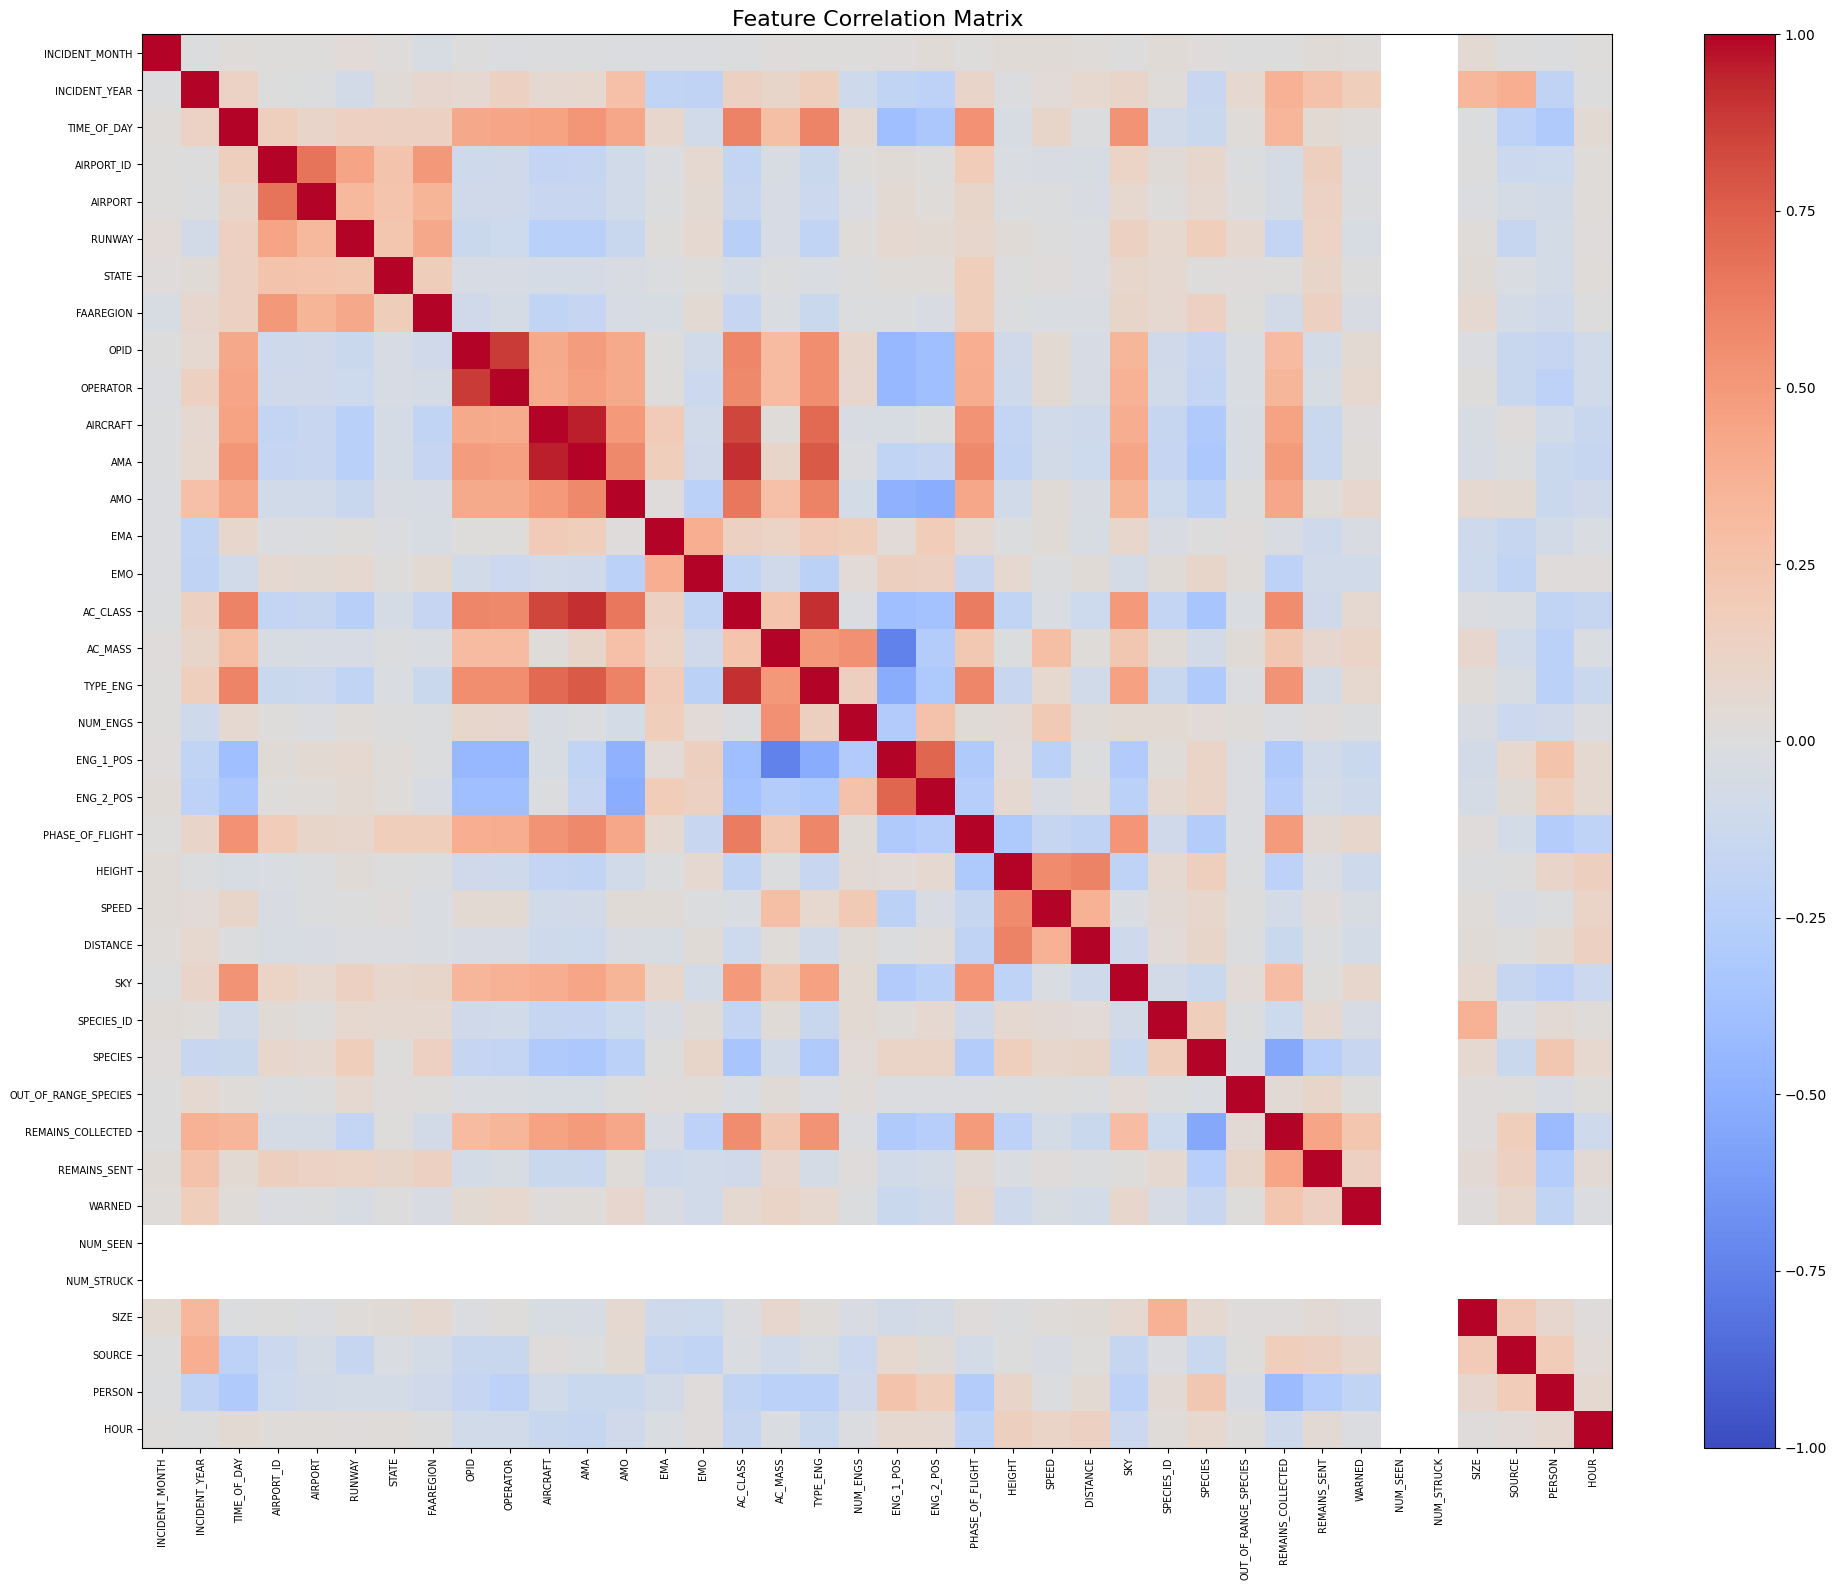

Top 15 features most correlated with INDICATED_DAMAGE:
SIZE                 0.268432
AC_MASS              0.228270
TYPE_ENG             0.205368
ENG_1_POS            0.177108
AC_CLASS             0.153370
SPECIES_ID           0.139793
INCIDENT_YEAR        0.138649
OPERATOR             0.134072
PHASE_OF_FLIGHT      0.131628
AMO                  0.130590
OPID                 0.121161
REMAINS_COLLECTED    0.118433
AMA                  0.112025
HEIGHT               0.110989
SKY                  0.108429
dtype: float64


c:\Users\karan\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\karan\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [38]:
# Making similarity matrix to see if data is clusterable (We aren't clustering)
# Sample 5000 rows — computing on 307k rows is too slow
X_sample = X_scaled.sample(n=5000, random_state=42)

corr_matrix = X_sample.corr()

fig, ax = plt.subplots(figsize=(20, 16))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

# Add colorbar
plt.colorbar(im, ax=ax)

# Add feature labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.columns, fontsize=7)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# Top features correlated with target 
target_corr = X_scaled.corrwith(y.reset_index(drop=True)).abs().sort_values(ascending=False)
print("Top 15 features most correlated with INDICATED_DAMAGE:")
print(target_corr.head(15))


In [39]:
# Dropping featues that have near-zero variance
zero_var_cols = ["NUM_SEEN", "NUM_STRUCK", "OUT_OF_RANGE_SPECIES"]
for col in zero_var_cols:
    if col in X_scaled.columns:
        X_scaled = X_scaled.drop(columns=[col])

# Drop zero-variance columns from test set
for col in zero_var_cols:
    if col in X_test_scaled.columns:
        X_test_scaled = X_test_scaled.drop(columns=[col])

print("Remaining training features:", X_scaled.shape[1])
print("Remaining test features:", X_test_scaled.shape[1])

Remaining training features: 35
Remaining test features: 35


In [40]:
# Fill any remaining NaNs with 0 (= median after RobustScaler)
X_scaled = X_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

print("NaNs remaining in X_scaled:", X_scaled.isnull().sum().sum())
print("NaNs remaining in X_test_scaled:", X_test_scaled.isnull().sum().sum())

# Reset and clean y before model training
y = df["INDICATED_DAMAGE"].reset_index(drop=True)

# Drop any rows where target is NaN
mask = y.notna()
y = y[mask].reset_index(drop=True)
X_scaled = X_scaled[mask].reset_index(drop=True)

print("NaNs in y:", y.isnull().sum())
print("X_scaled shape:", X_scaled.shape)
print("Class counts:\n", y.value_counts())

NaNs remaining in X_scaled: 0
NaNs remaining in X_test_scaled: 0
NaNs in y: 0
X_scaled shape: (307178, 35)
Class counts:
 INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64


X_scaled, _, y, _ = train_test_split(
    X_scaled, y,
    train_size=0.3,
    stratify=y,      # preserves the 93/6 class balance
    random_state=42
)
print("Reduced training size:", X_scaled.shape)

In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate scale_pos_weight to handle class imbalance (replaces class_weight="balanced")
neg = (y == 0).sum()
pos = (y == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

xgb_params = {
    "n_estimators":     [200, 300, 500],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [3, 5, 7],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma":            [0, 0.1, 0.5],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1, 2, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale,   # handles 93/6 imbalance
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),
    xgb_params, n_iter=30, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
xgb_search.fit(X_scaled, y)
best_xgb = xgb_search.best_estimator_

xgb_scores = cross_val_score(best_xgb, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print(f"XGBoost CV Balanced Accuracy: {xgb_scores.mean():.4f} +/- {xgb_scores.std():.4f}")
print(f"Best params: {xgb_search.best_params_}")

scale_pos_weight: 14.73
XGBoost CV Balanced Accuracy: 0.8300 +/- 0.0045
Best params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [48]:
# Get predicted probabilities on training set
y_proba_train = best_xgb.predict_proba(X_scaled)[:, 1]

# Get predicted probabilities on test set
y_proba_test = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Find best threshold using training data
best_thresh, best_score = 0.5, 0
for thresh in [i/100 for i in range(10, 60)]:
    preds = (y_proba_train >= thresh).astype(int)
    score = balanced_accuracy_score(y, preds)
    if score > best_score:
        best_score = score
        best_thresh = thresh

print(f"Best threshold: {best_thresh}")
print(f"Train Balanced Accuracy: {best_score:.4f}")

Best threshold: 0.49
Train Balanced Accuracy: 0.8533


In [50]:
# Apply best threshold to test set
y_pred_tuned = (y_proba_test >= best_thresh).astype(int)

# Build and save submission
submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred_tuned
})
submission.to_csv("submission_tuned.csv", index=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# DECISION STUMP (Decision Tree with max_depth=1)
stump_params = {
    "class_weight": ["balanced"],
    "criterion":    ["gini", "entropy"],
    "splitter":     ["best", "random"]
}
stump_search = RandomizedSearchCV(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    stump_params, n_iter=6, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
stump_search.fit(X_scaled, y)
best_stump = stump_search.best_estimator_

stump_scores = cross_val_score(best_stump, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Decision Stump ──")
print(f"  Best params: {stump_search.best_params_}")
print(f"  CV Balanced Accuracy: {stump_scores.mean():.4f} +/- {stump_scores.std():.4f}")

# BAGGING
bagging_params = {
    "n_estimators":      [50, 100, 200],
    "max_samples":       [0.7, 0.8, 1.0],
    "max_features":      [0.7, 0.8, 1.0],
    "bootstrap":         [True, False]
}
bagging_search = RandomizedSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
        random_state=42
    ),
    bagging_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
bagging_search.fit(X_scaled, y)
best_bagging = bagging_search.best_estimator_

bagging_scores = cross_val_score(best_bagging, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Bagging ──")
print(f"  Best params: {bagging_search.best_params_}")
print(f"  CV Balanced Accuracy: {bagging_scores.mean():.4f} +/- {bagging_scores.std():.4f}")

# RANDOM FOREST
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    rf_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
rf_search.fit(X_scaled, y)
best_rf = rf_search.best_estimator_

rf_scores = cross_val_score(best_rf, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Random Forest ──")
print(f"  Best params: {rf_search.best_params_}")
print(f"  CV Balanced Accuracy: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")

# BOOSTING (Gradient Boosting)
boost_params = {
    "n_estimators":      [100, 200, 300],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "max_depth":         [3, 4, 5],
    "subsample":         [0.7, 0.8, 1.0],
    "min_samples_leaf":  [1, 2, 4]
}
boost_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    boost_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
boost_search.fit(X_scaled, y)
best_boost = boost_search.best_estimator_

boost_scores = cross_val_score(best_boost, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Boosting ──")
print(f"  Best params: {boost_search.best_params_}")
print(f"  CV Balanced Accuracy: {boost_scores.mean():.4f} +/- {boost_scores.std():.4f}")

# MULTICLASS PARTITIONING (One-vs-Rest)
ovr_params = {
    "estimator__C":        [0.01, 0.1, 1, 10],
    "estimator__solver":   ["lbfgs", "saga"],
    "estimator__max_iter": [200, 500]
}
ovr_search = RandomizedSearchCV(
    OneVsRestClassifier(LogisticRegression(class_weight="balanced", random_state=42)),
    ovr_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
ovr_search.fit(X_scaled, y)
best_ovr = ovr_search.best_estimator_

ovr_scores = cross_val_score(best_ovr, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Multiclass Partitioning (OvR) ──")
print(f"  Best params: {ovr_search.best_params_}")
print(f"  CV Balanced Accuracy: {ovr_scores.mean():.4f} +/- {ovr_scores.std():.4f}")

# STACKING
stacking = StackingClassifier(
    estimators=[
        ("stump",   best_stump),
        ("bagging", best_bagging),
        ("rf",      best_rf),
        ("boost",   best_boost),
        ("ovr",     best_ovr)
    ],
    final_estimator=LogisticRegression(class_weight="balanced", random_state=42),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_scaled, y)

stacking_scores = cross_val_score(stacking, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Stacking ──")
print(f"  CV Balanced Accuracy: {stacking_scores.mean():.4f} +/- {stacking_scores.std():.4f}")


# VOTING ENSEMBLE (best models combined)
voting = VotingClassifier(
    estimators=[
        ("stump",    best_stump),
        ("bagging",  best_bagging),
        ("rf",       best_rf),
        ("boost",    best_boost),
        ("ovr",      best_ovr),
        ("stacking", stacking)
    ],
    voting="soft",
    n_jobs=-1
)
voting.fit(X_scaled, y)

voting_scores = cross_val_score(voting, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Voting Ensemble ──")
print(f"  CV Balanced Accuracy: {voting_scores.mean():.4f} +/- {voting_scores.std():.4f}/")

results = {
    "Decision Stump":          stump_scores.mean(),
    "Bagging":                 bagging_scores.mean(),
    "Random Forest":           rf_scores.mean(),
    "Boosting":                boost_scores.mean(),
    "Multiclass Part. (OvR)": ovr_scores.mean(),
    "Stacking":                stacking_scores.mean(),
    "Voting Ensemble":         voting_scores.mean()
}
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<28} {score:.4f}")

print(f"Best model: {max(results, key=results.get)}")
print(f"Best Balanced Accuracy: {max(results.values()):.4f}")

#  Generate predictions using best voting ensemble
y_pred = voting.predict(X_test_scaled)

# Build submission file
submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred
})

submission.to_csv("submission.csv", index=False)
print(submission["INDICATED_DAMAGE"].value_counts())
print(submission["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))